# Shipment / Route Analysis

In [1]:
# Imports
import boto3
from sagemaker import get_execution_role
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
role = get_execution_role()
bucket = 'jameel-saccoh-ads508'
deliverylog = 'Delivery_Logistics.csv'
dscl = 'dynamic_supply_chain_logistics_dataset.csv'
tradecustoms = 'trade_customs_dataset.csv'
del_form = 's3://{}/{}'.format(bucket, deliverylog)
dyn_form = 's3://{}/{}'.format(bucket, dscl)
trade_form = 's3://{}/{}'.format(bucket, tradecustoms)

In [3]:
#!pip install openpyxl # dependency
delivery = pd.read_csv(del_form)
dynamic = pd.read_csv(dyn_form)
trade = pd.read_csv(trade_form)

In [7]:
trade.head()

,Shipment_ID,Origin_Country,Destination_Country,Shipment_Date,Estimated_Arrival_Date,Actual_Arrival_Date,Transport_Mode,Carrier_Name,Route_Code,Commodity_Type,...,HS_Code,Document_Status,Compliance_Score,Prior_Offense_Count,Tariff_Category,Route_Risk_Index,Inspection_Type,Delay_Reason,Customs_Delay_Days,Risk_Flag
0,SHP000001,India,China,2022-01-31,2022-02-12,2022-02-15,Air,Carrier_9,R854,Electronics,...,9935.21,Error,0.49,3,Low,0.16,Physical,"Incomplete paperwork, requires manual review",3,1
1,SHP000002,Germany,Brazil,2024-08-31,2024-09-24,2024-09-25,Sea,Carrier_36,R303,Machinery,...,9928.63,Complete,0.76,3,High,0.71,Document,Routine customs clearance without issue,1,1
2,SHP000003,China,Germany,2023-09-28,2023-10-13,2023-10-13,Road,Carrier_10,R320,Automotive,...,2674.21,Missing,0.58,0,Medium,0.52,Document,Incorrect HS code classification,0,0
3,SHP000004,Brazil,China,2024-02-25,2024-03-18,2024-03-21,Sea,Carrier_25,R180,Food,...,5803.90,Error,0.77,2,High,0.14,Physical,"Suspected undervaluation, needs reassessment",3,1
4,SHP000005,India,China,2021-07-22,2021-08-20,2021-08-20,Road,Carrier_6,R975,Pharmaceuticals,...,2654.58,Missing,0.52,3,High,0.51,Document,High-risk commodity flagged for inspection,0,0


In [8]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Shipment_ID             10000 non-null  object 
 1   Origin_Country          10000 non-null  object 
 2   Destination_Country     10000 non-null  object 
 3   Shipment_Date           10000 non-null  object 
 4   Estimated_Arrival_Date  10000 non-null  object 
 5   Actual_Arrival_Date     10000 non-null  object 
 6   Transport_Mode          10000 non-null  object 
 7   Carrier_Name            10000 non-null  object 
 8   Route_Code              10000 non-null  object 
 9   Commodity_Type          10000 non-null  object 
 10  Declared_Value_USD      10000 non-null  float64
 11  Weight_kg               10000 non-null  float64
 12  HS_Code                 10000 non-null  float64
 13  Document_Status         10000 non-null  object 
 14  Compliance_Score        10000 non-null 

In [9]:
trade["Shipment_Date"] = pd.to_datetime(trade["Shipment_Date"])
trade["Estimated_Arrival_Date"] = pd.to_datetime(trade["Estimated_Arrival_Date"])
trade["Actual_Arrival_Date"] = pd.to_datetime(trade["Actual_Arrival_Date"])

trade["Transit_Delay_Days"] = (
    trade["Actual_Arrival_Date"] - trade["Estimated_Arrival_Date"]
).dt.days

trade["Is_Delayed"] = (trade["Transit_Delay_Days"] > 0).astype(int)

In [10]:
trade["Transit_Delay_Days"].describe()

count    10000.000000
mean         2.059500
std          2.234784
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         13.000000
Name: Transit_Delay_Days, dtype: float64

In [11]:
trade["Is_Delayed"].mean()

0.6307

In [12]:
trade_sub = trade[[
    'Origin_Country',
    'Destination_Country',
    'Transport_Mode',
    'Carrier_Name',
    'Route_Code',
    'Route_Risk_Index',
    'Customs_Delay_Days',
    'Weight_kg',
    'Declared_Value_USD'
]].copy()

# Info + missing
print(trade_sub.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Origin_Country       10000 non-null  object 
 1   Destination_Country  10000 non-null  object 
 2   Transport_Mode       10000 non-null  object 
 3   Carrier_Name         10000 non-null  object 
 4   Route_Code           10000 non-null  object 
 5   Route_Risk_Index     10000 non-null  float64
 6   Customs_Delay_Days   10000 non-null  int64  
 7   Weight_kg            10000 non-null  float64
 8   Declared_Value_USD   10000 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 703.3+ KB
None


In [13]:
# Top routes
routes = trade_sub.groupby(
    ['Origin_Country', 'Destination_Country']
).size().reset_index(name='count')

print(routes.sort_values('count', ascending=False).head(10))

   Origin_Country Destination_Country  count
35        Germany                 USA    139
57   South Africa             Germany    133
80             UK                 USA    128
76             UK               India    128
1       Australia               China    127
77             UK               Japan    127
24          China                 UAE    126
6       Australia                 UAE    126
70            UAE                  UK    124
88            USA                 UAE    123


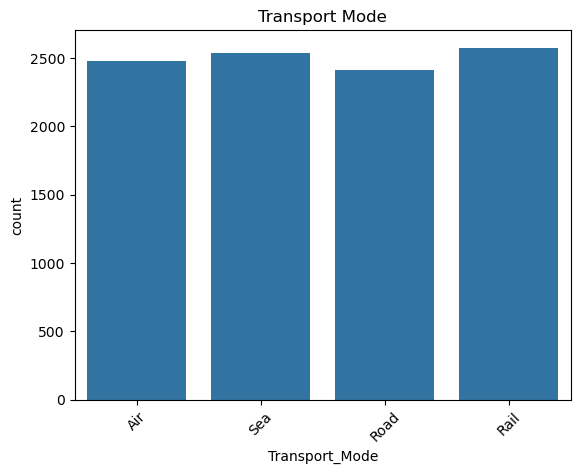

In [14]:
# Transport mode distribution
sns.countplot(data=trade_sub, x='Transport_Mode')
plt.xticks(rotation=45)
plt.title('Transport Mode')
plt.show()

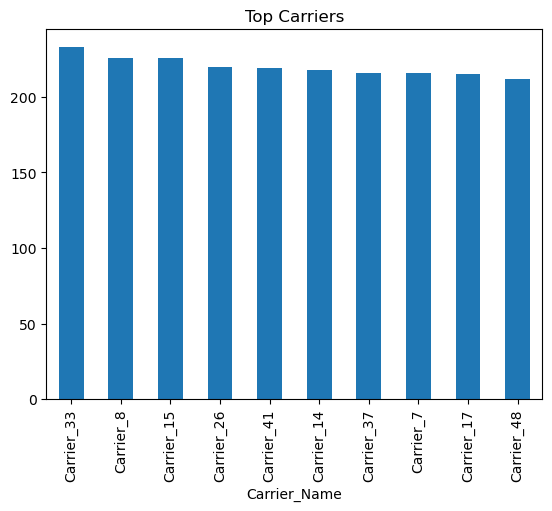

In [15]:
# Carrier distribution
trade_sub['Carrier_Name'].value_counts().head(10).plot(kind='bar')
plt.title('Top Carriers')
plt.show()

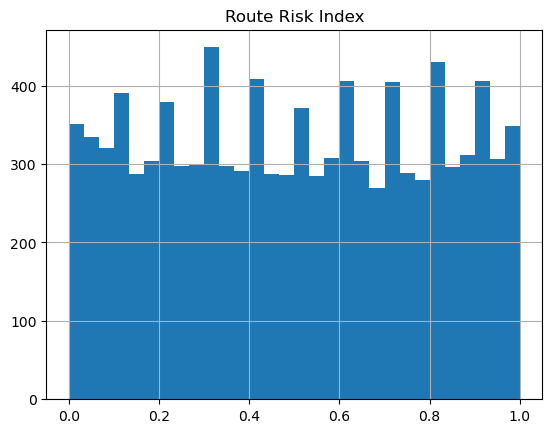

In [16]:
# Route risk distribution
trade_sub['Route_Risk_Index'].hist(bins=30)
plt.title('Route Risk Index')
plt.show()

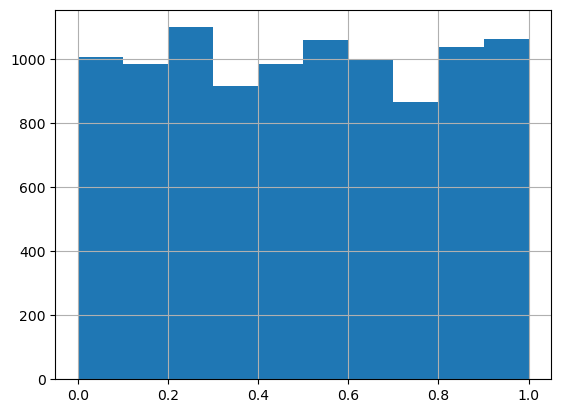

In [17]:
trade["Route_Risk_Index"].hist()
plt.show()

In [18]:
# Delay vs transport mode
print(trade_sub.groupby('Transport_Mode')['Customs_Delay_Days'].mean())

Transport_Mode
Air     2.057351
Rail    2.072621
Road    2.071281
Sea     2.037066
Name: Customs_Delay_Days, dtype: float64


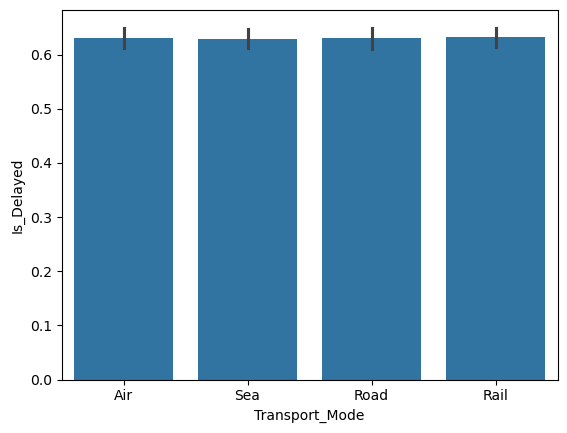

In [19]:
sns.barplot(data=trade, x="Transport_Mode", y="Is_Delayed")
plt.show()

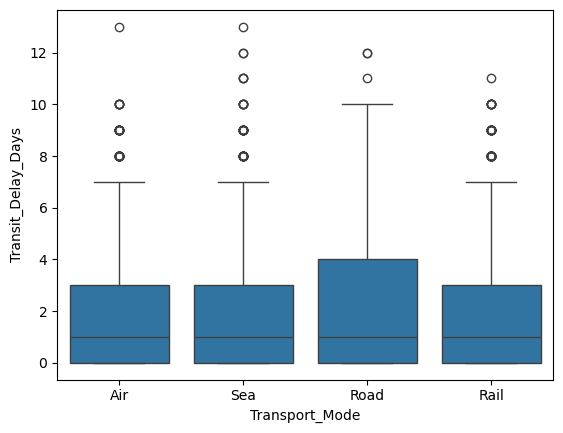

In [20]:
sns.boxplot(data=trade, x="Transport_Mode", y="Transit_Delay_Days")
plt.show()

In [21]:
delivery_sub = delivery[[
    'delivery_mode',
    'vehicle_type',
    'delivery_partner',
    'distance_km',
    'delivery_time_hours',
    'expected_time_hours',
    'delayed',
    'delivery_cost'
]].copy()

# Info + missing
print(delivery_sub.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_mode        25000 non-null  object 
 1   vehicle_type         25000 non-null  object 
 2   delivery_partner     25000 non-null  object 
 3   distance_km          25000 non-null  float64
 4   delivery_time_hours  25000 non-null  object 
 5   expected_time_hours  25000 non-null  object 
 6   delayed              25000 non-null  object 
 7   delivery_cost        25000 non-null  float64
dtypes: float64(2), object(6)
memory usage: 1.5+ MB
None


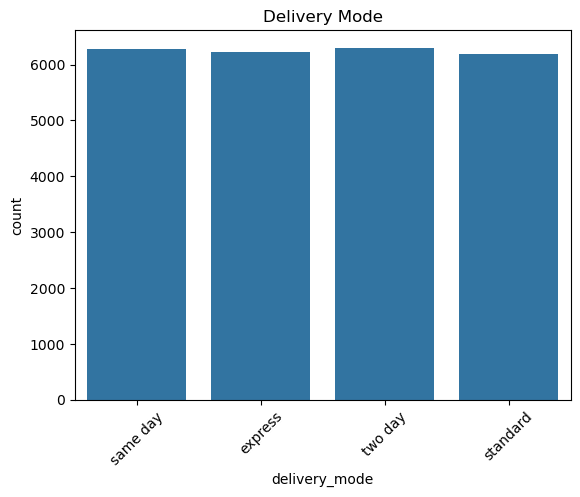

In [22]:
# Shipping mode
sns.countplot(data=delivery_sub, x='delivery_mode')
plt.xticks(rotation=45)
plt.title('Delivery Mode')
plt.show()

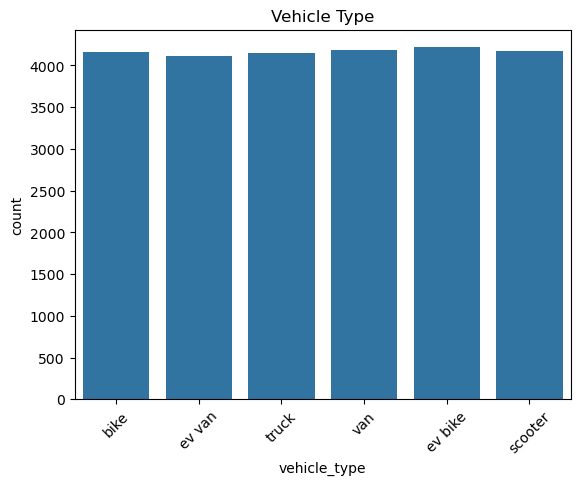

In [23]:
# Vehicle type
sns.countplot(data=delivery_sub, x='vehicle_type')
plt.xticks(rotation=45)
plt.title('Vehicle Type')
plt.show()

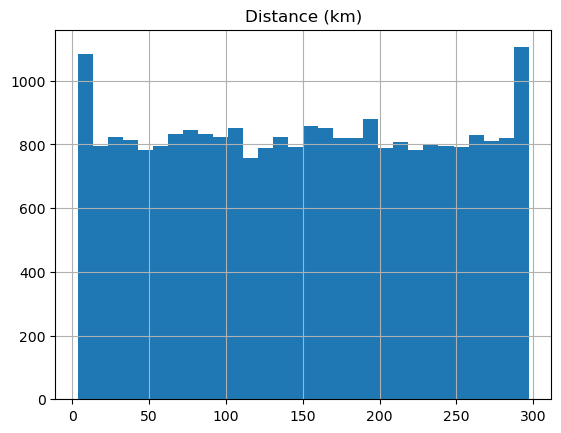

In [24]:
# Distance distribution
delivery_sub['distance_km'].hist(bins=30)
plt.title('Distance (km)')
plt.show()

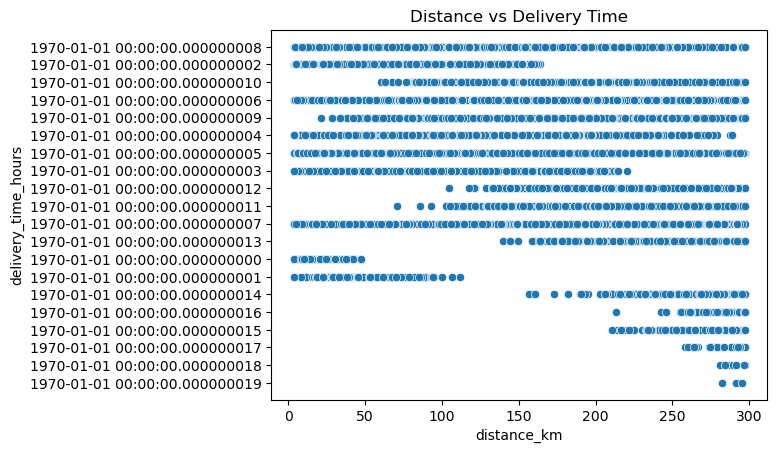

In [25]:
# Distance vs delivery time
sns.scatterplot(data=delivery_sub, x='distance_km', y='delivery_time_hours')
plt.title('Distance vs Delivery Time')
plt.show()


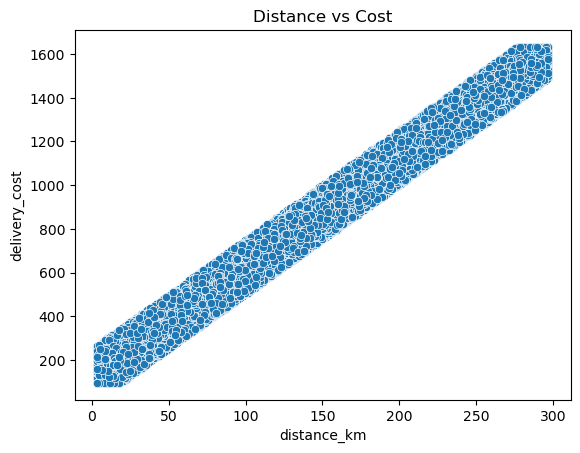

In [27]:
# Cost vs distance
sns.scatterplot(data=delivery_sub, x='distance_km', y='delivery_cost')
plt.title('Distance vs Cost')
plt.show()

In [4]:
supply_sub = dynamic[[
    'route_risk_level',
    'shipping_costs',
    'lead_time_days',
    'customs_clearance_time',
    'port_congestion_level',
    'traffic_congestion_level',
    'eta_variation_hours',
    'delivery_time_deviation'
]].copy()

# Info + missing
print(supply_sub.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   route_risk_level          32065 non-null  float64
 1   shipping_costs            32065 non-null  float64
 2   lead_time_days            32065 non-null  float64
 3   customs_clearance_time    32065 non-null  float64
 4   port_congestion_level     32065 non-null  float64
 5   traffic_congestion_level  32065 non-null  float64
 6   eta_variation_hours       32065 non-null  float64
 7   delivery_time_deviation   32065 non-null  float64
dtypes: float64(8)
memory usage: 2.0 MB
None


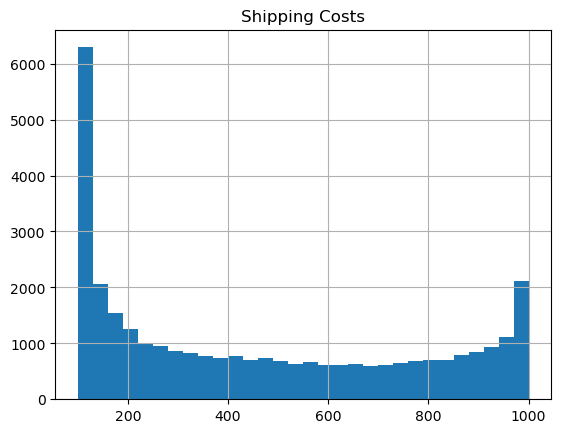

In [7]:
# Shipping cost distribution
supply_sub['shipping_costs'].hist(bins=30)
plt.title('Shipping Costs')
plt.show()

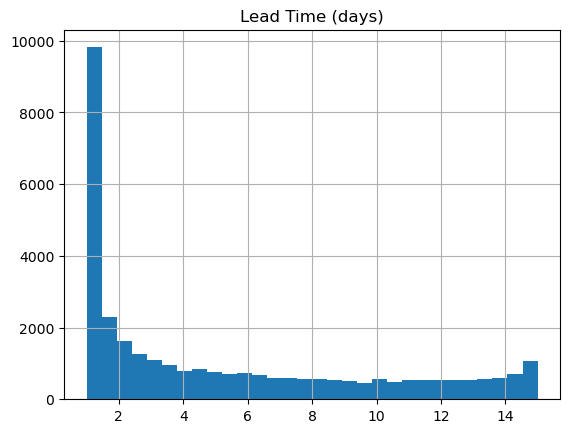

In [6]:
# Lead time distribution
supply_sub['lead_time_days'].hist(bins=30)
plt.title('Lead Time (days)')
plt.show()


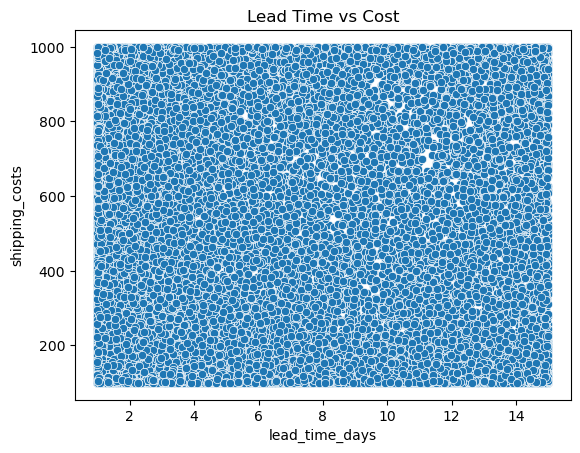

In [5]:
# Cost vs lead time
sns.scatterplot(data=supply_sub, x='lead_time_days', y='shipping_costs')
plt.title('Lead Time vs Cost')
plt.show()


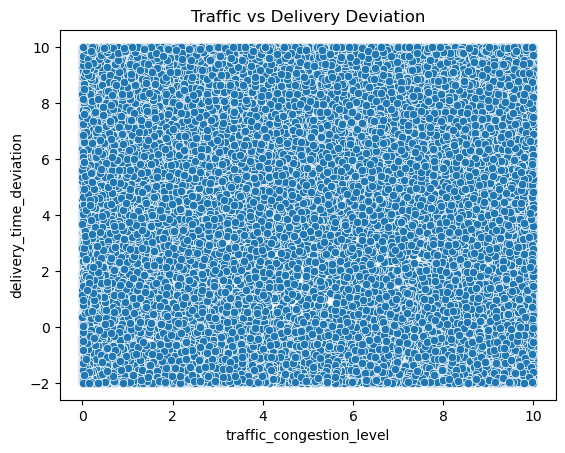

In [8]:
# Congestion vs delay
sns.scatterplot(
    data=supply_sub,
    x='traffic_congestion_level',
    y='delivery_time_deviation'
)
plt.title('Traffic vs Delivery Deviation')
plt.show()

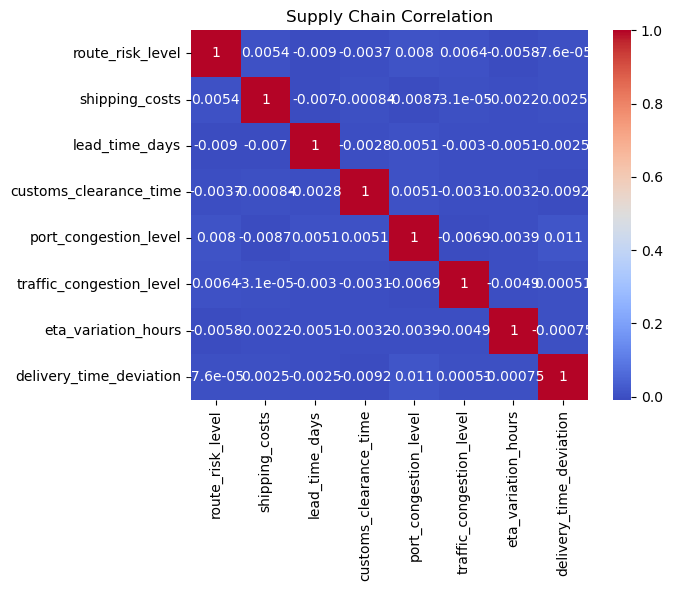

In [9]:
# Correlation
corr = supply_sub.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Supply Chain Correlation')
plt.show()